<a href="https://colab.research.google.com/github/AYMAN-CHAREF/machine-learning-et-deep-learning/blob/main/R%C3%A9gression_Multiple_Numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Régression Multiples Variables Numpy
 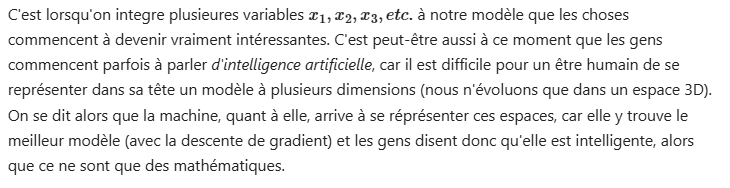

In [26]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# 1. Dataset
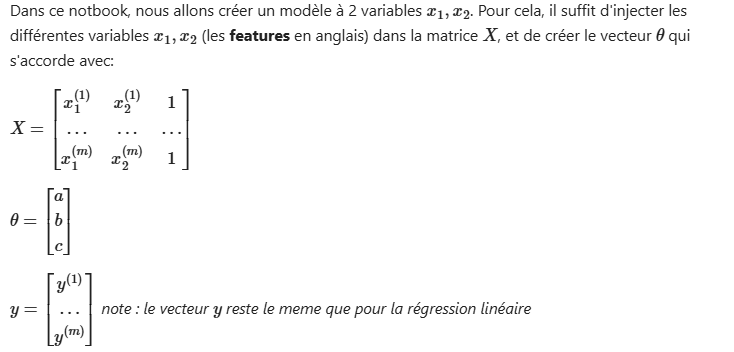

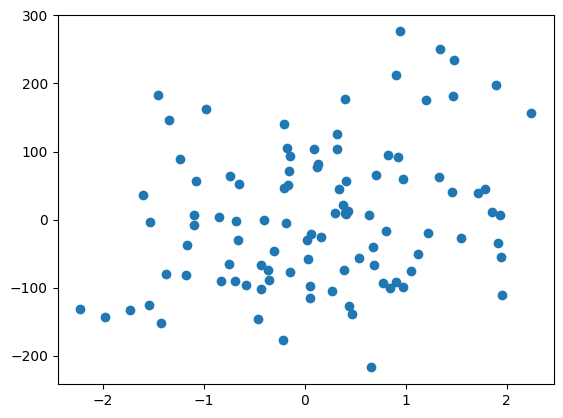

In [28]:
np.random.seed(0) # permet de reproduire l'aléatoire

x, y = make_regression(n_samples=100, n_features=2, noise = 10) # creation d'un dataset (x, y) linéaire

plt.scatter(x[:,0], y) # afficher les résultats. x_1 en abscisse et y en ordonnée

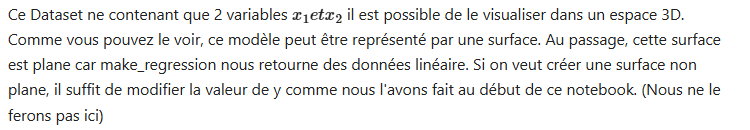

In [30]:
print(x.shape)
print(y.shape)

(100, 2)
(100,)


In [31]:
# redimensionner y
y = y.reshape(y.shape[0], 1)

print(y.shape)

(100, 1)


In [32]:
print(x.shape)
print(y.shape)

(100, 2)
(100, 1)


Création de la matrice X qui contient la colonne de Biais. Pour ca, on colle l'un contre l'autre le vecteur x et un vecteur 1 (avec np.ones) de dimension égale a celle de x

In [34]:
# Création de la matrice X, inclut le Biais
X = np.hstack((x, np.ones((x.shape[0], 1)))) # ajoute un vecteur Biais de dimension (x.shape[0], 1)

print(X.shape)
print(X[:10])

(100, 3)
[[ 1.05445173 -1.07075262  1.        ]
 [-0.36274117 -0.63432209  1.        ]
 [-0.85409574  0.3130677   1.        ]
 [ 1.3263859   0.29823817  1.        ]
 [-0.4615846  -1.31590741  1.        ]
 [ 1.94362119 -1.17312341  1.        ]
 [-1.60205766  0.62523145  1.        ]
 [-0.40178094  0.17742614  1.        ]
 [-0.97727788  1.86755799  1.        ]
 [ 0.37816252  0.15494743  1.        ]]


In [35]:
X

array([[ 1.05445173, -1.07075262,  1.        ],
       [-0.36274117, -0.63432209,  1.        ],
       [-0.85409574,  0.3130677 ,  1.        ],
       [ 1.3263859 ,  0.29823817,  1.        ],
       [-0.4615846 , -1.31590741,  1.        ],
       [ 1.94362119, -1.17312341,  1.        ],
       [-1.60205766,  0.62523145,  1.        ],
       [-0.40178094,  0.17742614,  1.        ],
       [-0.97727788,  1.86755799,  1.        ],
       [ 0.37816252,  0.15494743,  1.        ],
       [-0.30230275, -0.38732682,  1.        ],
       [-0.74745481, -0.41361898,  1.        ],
       [-0.18718385,  0.04575852,  1.        ],
       [ 0.31872765,  0.92085882,  1.        ],
       [-1.53624369,  0.46566244,  1.        ],
       [ 0.40015721,  1.76405235,  1.        ],
       [-0.82643854, -0.74475482,  1.        ],
       [-0.74216502,  0.8644362 ,  1.        ],
       [ 0.70657317,  0.3563664 ,  1.        ],
       [ 0.90082649, -1.16514984,  1.        ],
       [-0.57884966, -0.87079715,  1.   

In [36]:
# Initialisation du vecteur theta aléatoire, avec 3 éléments (car X a trois colonnes)
theta = np.random.randn(3, 1)
theta

array([[-0.82646112],
       [ 0.78420863],
       [-0.1954172 ]])

## 2. Modele Linéaire

On implémente un modele F = X.theta
, puis on teste le modele pour voir s'il n'y a pas de bug (bonne pratique oblige). En plus, cela permet de voir a quoi ressemble le modele initial, défini par la valeur de  theta

In [10]:
def model(X, theta):
    return X.dot(theta)

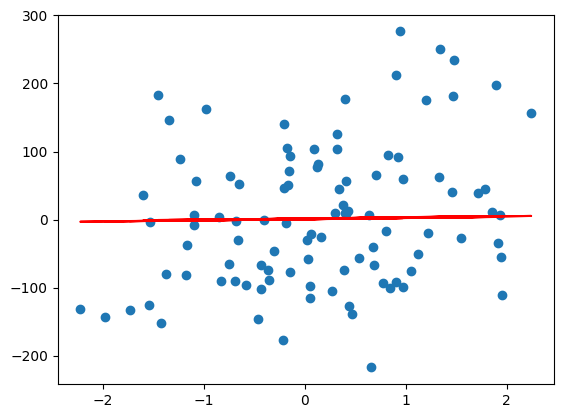

In [11]:
plt.scatter(x[:,0],y)
plt.plot(x[:,0],model(X, theta), c='r')

# 3. Fonction Cout : Erreur Quadratique moyenne

On mesure les erreurs du modele sur le Dataset X, y en implémenterl'erreur quadratique moyenne, Mean Squared Error (MSE) en anglais.


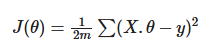


Ensuite, on teste notre fonction, pour voir s'il n'y a pas de bug

In [37]:
def cost_function (X, y, theta):
  m =len(y)
  return 1/(2*m) * np.sum((model(X,theta)-y)**2)

In [38]:
cost_function (X, y, theta)

np.float64(5294.071342926028)

# 4. Gradients et Descente de Gradient

On implémente la formule du gradient pour la MSE

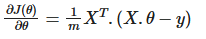

Ensuite on utilise cette fonction dans la descente de gradient:

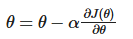

In [39]:
def grad(X, y, theta):
  m  = len(y)
  return 1/m * X.T.dot((model(X,theta)-y))

In [40]:
def gradient_descent(X, y, theta, learning_rate, n_iterations):

    cost_history = np.zeros(n_iterations) # création d'un tableau de stockage pour enregistrer l'évolution du Cout du modele

    for i in range(0, n_iterations):
        theta = theta - learning_rate * grad(X, y, theta) # mise a jour du parametre theta (formule du gradient descent)
        cost_history[i] = cost_function(X, y, theta) # on enregistre la valeur du Cout au tour i dans cost_history[i]

    return theta, cost_history

# 5. Phase d'entrainement

On définit un nombre d'itérations, ainsi qu'un pas d'apprentissage alpha, et c'est partit !

Une fois le modele entrainé, on observe les resultats par rapport a notre Dataset

In [41]:
n_iterations = 1000
learning_rate = 0.01


theta_final, cost_history = gradient_descent(X, y, theta, learning_rate, n_iterations)

In [42]:
# création d'un vecteur prédictions qui contient les prédictions de notre modele final
predictions = model(X, theta_final)

theta_final

array([[28.67154616],
       [97.29524926],
       [-0.511481  ]])

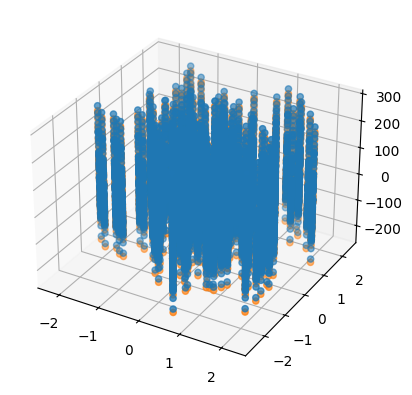

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x[:,0], x[:,1], y)
ax.scatter(x[:,0], x[:,1], predictions)

# 6. Courbes d'apprentissage

Pour vérifier si notre algorithme de Descente de gradient a bien fonctionné, on observe l'évolution de la fonction cout a travers les itérations. On est sensé obtenir une courbe qui diminue a chaque itération jusqu'a stagner a un niveau minimal (proche de zéro). Si la courbe ne suit pas ce motif, alors le pas learning_rate est peut-etre trop élevé, il faut prendre un pas plus faible.

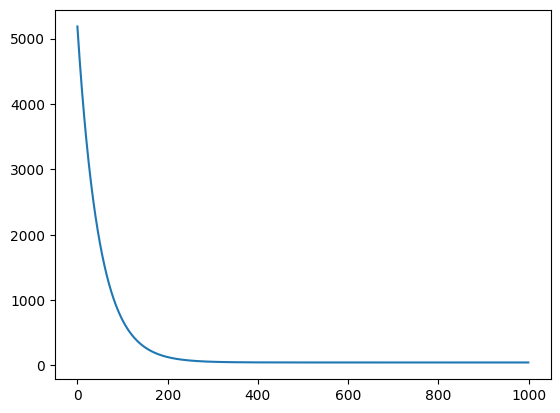

In [44]:
plt.plot(range(1000), cost_history)
plt.show()

# 7. Evaluation finale

Pour évaluer la réelle performance de notre modele avec une métrique populaire (pour votre patron, client, ou vos collegues) on peut utiliser le coefficient de détermination, aussi connu sous le nom R**2
. Il nous vient de la méthode des moindres carrés. Plus le résultat est proche de 1, meilleur est votre modele

In [45]:
def coef_determination(y, pred):
  u = ((y - pred)**2).sum()
  v = ((y - y.mean())**2).sum()
  return 1 - u/v

In [46]:
coef_determination(y, predictions)

np.float64(0.9916687122277607)